In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from scipy.spatial import cKDTree
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
from tools import *
from scipy.interpolate import splprep, splev
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D projection
from scipy.interpolate import make_smoothing_spline




In [39]:
# ==== USER PARAMETERS ====

SAMPLE = 0            # sample number of the data
POST_SAMPLE=6          #optional : when we want to compare 2 measurment of 2 patients or patient before and after
GRID_SIZE = 100        # Grid resolution for plotting or interpolation
A = 0.7                # Distance threshold to define a "distant" antigen
CLOSE_NEIGH = 0.25     # Radius threshold for regression surface - points which far form this point will not be clacualted
NORMALIZE = True       # Whether to normalize the X and Y coordinates
SMOOTH_FACTOR = 0.3    # Spline smoothing factor for the summary path
DATA_DIR='ferret_titration_results.csv'

### 1. Data processing

### 1.1 Import Data


In [40]:
df_antigenic_map=pd.read_csv("antigentic_map.csv")
df_ferret_results=pd.read_csv(DATA_DIR)

### 1.2 Pre-preocess Data

In [41]:
#preprocess- 
df_ferret_results=df_ferret_results.applymap(clean_titer)
df_ferret_results=df_ferret_results.iloc[:,2:].applymap(convert_titer)
ferret1=df_ferret_results.transpose()[SAMPLE]
ferret1=ferret1.rename("log_titers")
ferret1 = ferret1.dropna()  # drop missing titers just in case


/var/folders/m_/nq8htzlj5735r1l7c6m_ndcw0000gn/T/ipykernel_73678/1478356176.py:2: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.

/var/folders/m_/nq8htzlj5735r1l7c6m_ndcw0000gn/T/ipykernel_73678/1478356176.py:3: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



### 2. Antigenic Map

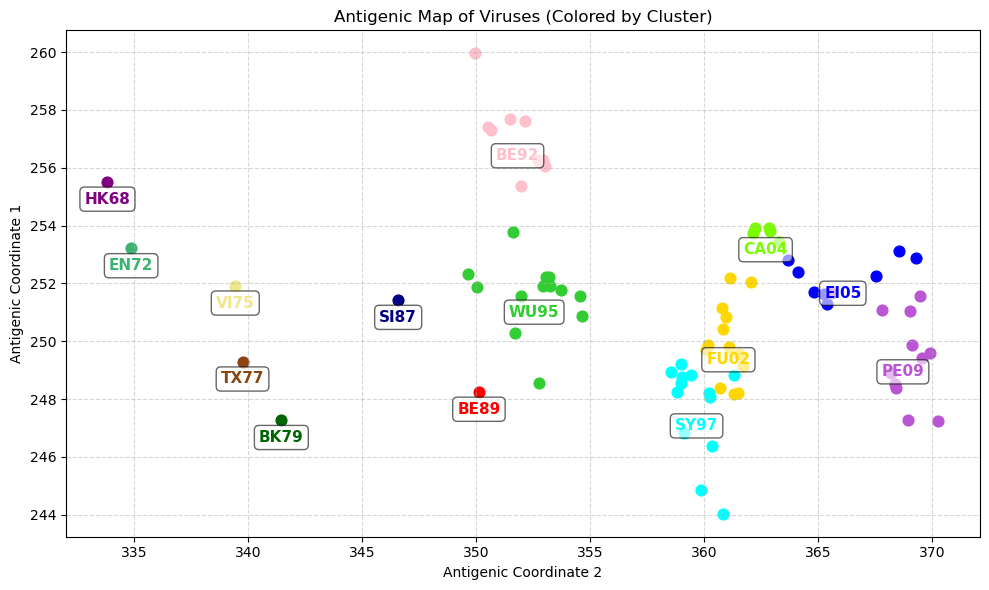

In [42]:
# # Create a color palette with one unique color per cluster
unique_clusters = df_antigenic_map['cluster'].unique()
# palette = sns.color_palette("hsv", len(unique_clusters))  # or "tab10", "Set2", etc.
# color_map = dict(zip(unique_clusters, palette))
color_map = {
    'HK68': 'purple',         # hard purple
    'EN72': 'mediumseagreen', # blue-green
    'VI75': 'khaki',          # dirty yellow
    'TX77': 'saddlebrown',    # brown
    'BK79': 'darkgreen',      # green bottle
    'SI87': 'navy',           # blue navy
    'BE89': 'red',            # red
    'BE92': 'pink',           # pink lady
    'WU95': 'limegreen',      # green grass
    'SY97': 'cyan',           # cyan
    'FU02': 'gold',           # yellow
    'CA04': 'lawngreen',      # glare green
    'EI05': 'blue',           # blue
    'PE09': 'mediumorchid'    # purple
}

# Plot
plt.figure(figsize=(10, 6))
for cluster in unique_clusters:
    cluster_df = df_antigenic_map[df_antigenic_map['cluster'] == cluster]
    plt.scatter(cluster_df['AG coordinate 2'], cluster_df['AG coordinate 1'],
                s=60, color=color_map[cluster], label=cluster)
    
    # Add cluster name text at the mean coordinate position
    x_mean = cluster_df['AG coordinate 2'].mean()
    y_mean = cluster_df['AG coordinate 1'].mean()-0.6
    plt.text(x_mean, y_mean, str(cluster), fontsize=11, weight='bold', 
             color=color_map[cluster], ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.6))

# Optional: Add virus names (can be uncommented if needed)
# for i in range(len(df)):
#     plt.text(df['AG coordinate 2'][i], df['AG coordinate 1'][i], df['viruses'][i],
#              fontsize=8, ha='right', va='bottom')

# Customize the grid and axis
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlabel('Antigenic Coordinate 2')
plt.ylabel('Antigenic Coordinate 1')
plt.title('Antigenic Map of Viruses (Colored by Cluster)')
plt.tight_layout()
plt.show()

### 3.Antibody Landscape

#### 3.1 Data processing


In [43]:
# Merge coordinates and titers for a single ferret sample
# Merge antigenic coordinates and titer data
df_landscape = df_antigenic_map.merge(ferret1, left_on='viruses', right_index=True)
df_landscape['color'] = df_landscape['cluster'].map(color_map)

if NORMALIZE:
    scaler = MinMaxScaler()
    df_landscape['AG coordinate 1']=scaler.fit_transform(df_landscape['AG coordinate 1'].values.reshape(-1, 1)).flatten()
    df_landscape['AG coordinate 2']=scaler.fit_transform(df_landscape['AG coordinate 2'].values.reshape(-1, 1)).flatten()

# Extract coordinates and colors
X = df_landscape['AG coordinate 2'].values
Y = df_landscape['AG coordinate 1'].values
Z = df_landscape['log_titers'].values
C = df_landscape['color']
cluster_label=df_landscape["cluster"].values

### 3.2: 3d Antibody Landscape

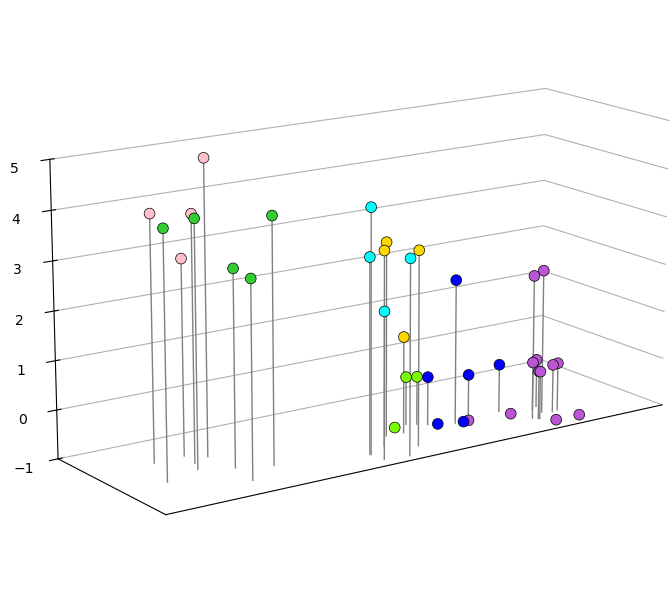

In [44]:
plot_3d_antibody(X,Y,Z,C)

### 3.3 antibody summary path 

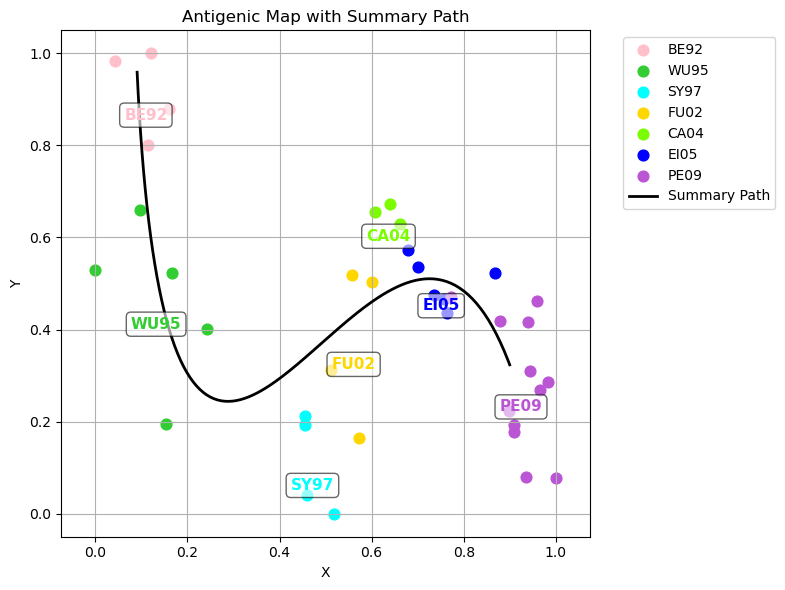

In [45]:
def find_summary_path(df_landscape):

    # Get unique clusters
    unique_clusters = df_landscape['cluster'].unique()

    # Compute centroids and sort from left to right (based on x)
    df_centroids = (
        df_landscape
        .groupby('cluster')[['AG coordinate 1', 'AG coordinate 2']]
        .mean()
        .reset_index()
        .rename(columns={'AG coordinate 2': 'x', 'AG coordinate 1': 'y'})
        .sort_values(by='x')
    )

    # Fit a smooth spline through centroids
    points = df_centroids[['x', 'y']].values
    tck, u = splprep([points[:, 0], points[:, 1]], s=SMOOTH_FACTOR)
    unew = np.linspace(0, 1, 200)
    x_smooth, y_smooth = splev(unew, tck)
    summary_path = np.column_stack((x_smooth, y_smooth))



    #plot summary_path
    plt.figure(figsize=(8, 6))

    # Plot clusters
    for cluster in unique_clusters:
        cluster_df = df_landscape[df_landscape['cluster'] == cluster]
        plt.scatter(cluster_df['AG coordinate 2'], cluster_df['AG coordinate 1'],
                    s=60, color=color_map[cluster], label=cluster)

        x_mean = cluster_df['AG coordinate 2'].mean()
        y_mean = cluster_df['AG coordinate 1'].mean() - 0.05
        plt.text(x_mean, y_mean, str(cluster), fontsize=11, weight='bold',
                color=color_map[cluster], ha='center', va='center',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.6))

    # Plot summary path
    plt.plot(x_smooth, y_smooth, color='black', linewidth=2, label='Summary Path')


    plt.title('Antigenic Map with Summary Path')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.grid(True)
    plt.axis('equal')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    return x_smooth,y_smooth,df_centroids

x_smooth,y_smooth,df_centroids=find_summary_path(df_landscape)

## Plot 2: 3d Antibody Surface

the RMSE is :0.9134855666226361


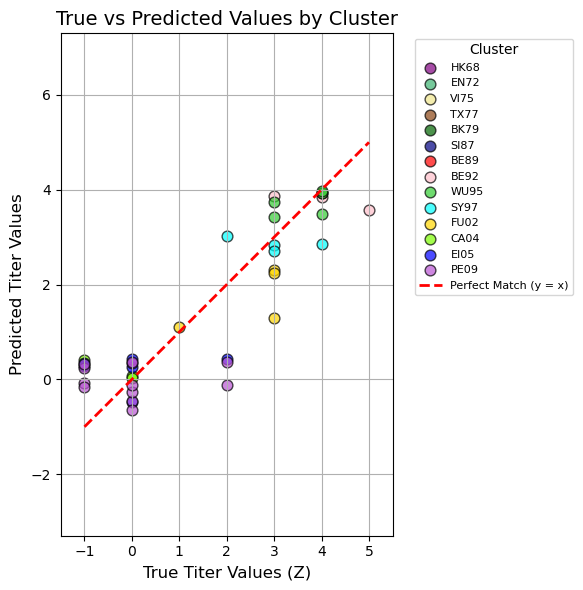

In [46]:

def compute_surface_regression(X,Y,Z,GRID_SIZE,A,cluster_label,unique_clusters):
    # Step 1: Create grid over antigenic map
    x_range = np.linspace(0 , 1 , GRID_SIZE)
    y_range = np.linspace(0 , 1 , GRID_SIZE)
    xj, yj = np.meshgrid(x_range, y_range)


    # Step 2: Compute distances and weights (tricubic)
    aij = np.sqrt((X[:, None, None] - xj) ** 2 + (Y[:, None, None] - yj) ** 2)
    weights = np.where(aij <= A, (1 - (aij / A) ** 3) ** 3, 0)

    #closest entigen in the map
    min_dist_to_grid = np.min(aij, axis=0)
    landscape_z = np.zeros_like(xj)

    #Step 3 : looop over each point on the surface and predict the z vlaue by weighted linear regression
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):

            # Condition1 : If the closest antigenic point is too far, skip
            if min_dist_to_grid[i, j] > CLOSE_NEIGH:
                landscape_z[i, j] = np.nan
                continue
            
            # Condition 2: if the sum of the weights are 0 - it means very far point
            w = weights[:, i, j]
            if np.sum(w) == 0:
                landscape_z[i, j] = np.nan
                print("null becasue sum weight is 0")
                continue

            # Condtion 3 
            X_design = sm.add_constant(np.column_stack((X, Y)))
            try:
                model = sm.WLS(Z, X_design, weights=w)
                results = model.fit()
                beta = results.params
                landscape_z[i, j] = beta[0] + beta[1] * xj[i, j] + beta[2] * yj[i, j]
            except:
                landscape_z[i, j] = np.nan
                print("null becasue couldnt reach linera regression")

    # Step 4: Find corresponding surface height at each (X, Y)
    # Locate closest grid point index
    x_idx = np.searchsorted(x_range, X) - 1
    y_idx = np.searchsorted(y_range, Y) - 1

    # Clip indices to stay within grid bounds
    x_idx = np.clip(x_idx, 0, GRID_SIZE - 1)
    y_idx = np.clip(y_idx, 0, GRID_SIZE - 1)

    # Get surface height at that grid point
    Z_surf_at_data = landscape_z[y_idx, x_idx]

    # Get surface height at that grid point
    predicted_z = landscape_z[y_idx, x_idx]
    rmse = np.sqrt(mean_squared_error(Z,predicted_z))
    print(f"the RMSE is :{rmse}")

    plot_error_scatter(Z,predicted_z,cluster_label,unique_clusters)
    return x_range,y_range,landscape_z,predicted_z


x_range,y_range,landscape_z,predicted_z =compute_surface_regression(X,Y,Z,GRID_SIZE,A,cluster_label,unique_clusters)


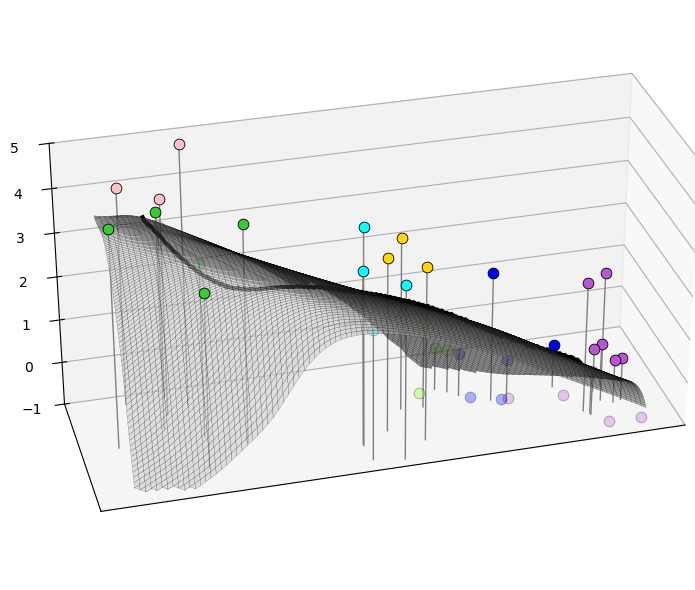

In [ ]:
def plot3d_antibody_surface(X,Y,Z,GRID_SIZE,landscape_z,x_range,y_range,x_smooth,y_smooth):

    ### Step 1: Calculate Z values for the surface and the summary path

    # -- Surface Z values (masked where Z <= -1)
    masked_z = np.where(landscape_z <= -1, np.nan, landscape_z)

    # Create facecolors from the colormap, handling NaNs with transparency
    facecolors = plt.cm.Blues(
        (masked_z - np.nanmin(masked_z)) / (np.nanmax(masked_z) - np.nanmin(masked_z))
    )
    facecolors[np.isnan(masked_z)] = (1, 1, 1, 0)  # Transparent for invalid values

    # -- Summary path Z values (interpolated from grid)
    x_idx_path = np.searchsorted(x_range, x_smooth) - 1
    y_idx_path = np.searchsorted(y_range, y_smooth) - 1
    x_idx_path = np.clip(x_idx_path, 0, landscape_z.shape[1] - 1)
    y_idx_path = np.clip(y_idx_path, 0, landscape_z.shape[0] - 1)
    z_path = landscape_z[y_idx_path, x_idx_path]

    # Mask invalid path points
    valid_mask = ~np.isnan(z_path)
    x_path_valid = x_smooth[valid_mask]
    y_path_valid = y_smooth[valid_mask]
    z_path_valid = z_path[valid_mask]


    ### Step 2: Calculate surface Z values at data points and transparency

    # Grid indices of (X, Y) sample locations
    x_idx = np.searchsorted(x_range, X) - 1
    y_idx = np.searchsorted(y_range, Y) - 1
    x_idx = np.clip(x_idx, 0, GRID_SIZE - 1)
    y_idx = np.clip(y_idx, 0, GRID_SIZE - 1)

    # Get Z values from surface at those indices
    Z_surf_at_data = landscape_z[y_idx, x_idx]  # Note: row first (Y), column second (X)

    # Compute alpha values: fade if below surface
    alpha_vals = np.where(Z < Z_surf_at_data, 0.3, 1)


    # --- Matplotlib 3D surface plot ---
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(xj, yj, masked_z, color='lightgray', rstride=1, cstride=1,
                    linewidth=0.1, antialiased=True, edgecolor='k', alpha=0.6, zorder=1)

    for x, y, z in zip(X, Y, Z):
        ax.plot([x, x], [y, y], [-1, z], color='gray', linewidth=1, alpha=1, zorder=2)

    for xi, yi, zi, ci, ai in zip(X, Y, Z, C, alpha_vals):
        ax.scatter(xi, yi, zi, color=ci, edgecolors='black', linewidths=0.6, alpha=ai,
                   s=60, depthshade=False, zorder=3)

    ax.plot(x_path_valid, y_path_valid, z_path_valid, color='black', linewidth=3,
            label='Summary Path', zorder=4)

    ax.set_zlabel('log₂(HI titer / 10)', labelpad=15, fontsize=12)
    ax.set_zlim(-1, Z.max())
    ax.set_xticks([])
    ax.set_yticks([])
    ax.view_init(elev=30, azim=255)
    ax.get_proj = lambda: np.dot(Axes3D.get_proj(ax), np.diag([1, 1.01, 1, 1]))
    ax.set_box_aspect(aspect=(3, 1, 1.5), zoom=1.2)

    plt.tight_layout()
    plt.show()

    # --- Plotly Interactive 3D Surface ---
    z_path_valid_3d = np.clip(z_path_valid, -1, z_path_valid.max())
    surface = go.Surface(
        x=xj,
        y=yj,
        z=masked_z,
        colorscale='Blues',
        showscale=False,
        opacity=0.8,
        cmin=np.nanmin(masked_z),
        cmax=np.nanmax(masked_z),
        name='Surface'
    )

    summary_path = go.Scatter3d(
        x=x_path_valid,
        y=y_path_valid,
        z=z_path_valid_3d,
        mode='lines',
        line=dict(color='black', width=6),
        name='Summary Path'
    )

    cluster_traces = []
    for cluster in unique_clusters:
        cluster_idx = cluster_label == cluster
        trace = go.Scatter3d(
            x=X[cluster_idx],
            y=Y[cluster_idx],
            z=Z[cluster_idx],
            mode='markers',
            marker=dict(
                size=6,
                color=color_map[cluster],
                line=dict(color='black', width=0.5),
                opacity=0.9
            ),
            name=f'{cluster}'
        )
        cluster_traces.append(trace)

    fig = go.Figure(data=[surface, summary_path] + cluster_traces)
    fig.update_layout(
        title='Interactive Antibody Landscape',
        scene=dict(
            xaxis_title='Antigenic X',
            yaxis_title='Antigenic Y',
            zaxis_title='log₂(HI titer / 10)',
            zaxis=dict(range=[-1, Z.max()])
        ),
        width=1000,
        height=700,
        legend=dict(title='Clusters')
    )

    fig.show()


    return masked_z,x_path_valid,y_path_valid,z_path_valid

masked_z,x_path_valid,y_path_valid,z_path_valid=plot3d_antibody_surface(X,Y,Z,GRID_SIZE,landscape_z,x_range,y_range,x_smooth,y_smooth)


In [48]:

# === Step 1: Flatten the surface for Plotly ===
xj, yj = np.meshgrid(x_range, y_range)

x_flat = xj.flatten()
y_flat = yj.flatten()
z_flat = masked_z.flatten()
valid = ~np.isnan(z_flat)

# === Step 2: Create Surface ===
surface = go.Surface(
    x=xj,
    y=yj,
    z=masked_z,
    colorscale='Blues',
    showscale=False,
    opacity=0.8,
    cmin=np.nanmin(masked_z),
    cmax=np.nanmax(masked_z),
    name='Surface'
)


# === Step 3: Create summary path ===
#clip z to -1
z_path_valid_3d=np.clip(z_path_valid,-1,z_path_valid.max())
summary_path = go.Scatter3d(
    x=x_path_valid,
    y=y_path_valid,
    z=z_path_valid_3d,
    mode='lines',
    line=dict(color='black', width=6),
    name='Summary Path'
)

# === Step 4: Cluster-colored virus points ===
cluster_traces = []
for cluster in unique_clusters:
    cluster_idx = cluster_label == cluster
    trace = go.Scatter3d(
        x=X[cluster_idx],
        y=Y[cluster_idx],
        z=Z[cluster_idx],
        mode='markers',
        marker=dict(
            size=6,
            color=color_map[cluster],
            line=dict(color='black', width=0.5),
            opacity=0.9
        ),
        name=f'{cluster}'
    )
    cluster_traces.append(trace)

# === Step 5: Combine all traces ===
fig = go.Figure(data=[surface, summary_path] + cluster_traces)

# === Step 6: Layout ===
fig.update_layout(
    title='Interactive Antibody Landscape',
    scene=dict(
        xaxis_title='Antigenic X',
        yaxis_title='Antigenic Y',
        zaxis_title='log₂(HI titer / 10)',
        zaxis=dict(range=[-1, Z.max()])
    ),
    width=1000,
    height=700,
    legend=dict(title='Clusters')
)

fig.show()

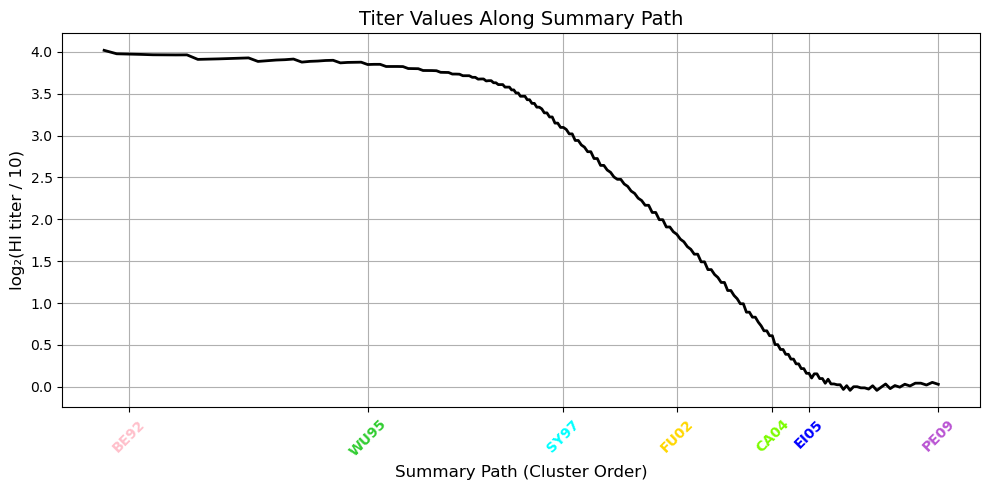

In [49]:
# Step 1: Compute distance along path (again, if not already)
path_deltas = np.sqrt(np.diff(x_path_valid)**2 + np.diff(y_path_valid)**2)
path_distance = np.concatenate([[0], np.cumsum(path_deltas)])  # x-axis

# Step 2: Find closest point on path for each cluster centroid
tick_positions = []
tick_labels = []
tick_colors = []

for i, row in df_centroids.iterrows():
    cluster_name = row['cluster']
    cx, cy = row['x'], row['y']

    # Compute distances to all points on the path
    dists = np.sqrt((x_path_valid - cx)**2 + (y_path_valid - cy)**2)
    closest_idx = np.argmin(dists)

    tick_positions.append(path_distance[closest_idx])
    tick_labels.append(str(cluster_name))
    tick_colors.append(color_map[cluster_name])  # Use your custom color map

# Step 3: Plot with colored x-tick labels
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(path_distance, z_path_valid, color='black', linewidth=2)

ax.set_xlabel('Summary Path (Cluster Order)', fontsize=12)
ax.set_ylabel('log₂(HI titer / 10)', fontsize=12)
ax.set_title('Titer Values Along Summary Path', fontsize=14)
ax.grid(True)

# Set tick positions
ax.set_xticks(tick_positions)

# Set tick labels with colors
tick_texts = ax.set_xticklabels(tick_labels, rotation=45)
for label, color in zip(tick_texts, tick_colors):
    label.set_color(color)
    label.set_fontweight('bold')

plt.tight_layout()
plt.show()

In [50]:
## compare 2 patients
#preprocess- 
ferret2=df_ferret_results.transpose()[POST_SAMPLE]
ferret2=ferret2.rename("log_titers")
ferret2 = ferret2.dropna()  # drop missing titers just in case


# Merge coordinates and titers for a single ferret sample
# Merge antigenic coordinates and titer data
df_landscape_2 = df_antigenic_map.merge(ferret2, left_on='viruses', right_index=True)
df_landscape_2['color'] = df_landscape_2['cluster'].map(color_map)

if NORMALIZE:
    scaler = MinMaxScaler()
    df_landscape_2['AG coordinate 1']=scaler.fit_transform(df_landscape_2['AG coordinate 1'].values.reshape(-1, 1)).flatten()
    df_landscape_2['AG coordinate 2']=scaler.fit_transform(df_landscape_2['AG coordinate 2'].values.reshape(-1, 1)).flatten()

# Extract coordinates and colors
X_2 = df_landscape_2['AG coordinate 2'].values
Y_2 = df_landscape_2['AG coordinate 1'].values
Z_2 = df_landscape_2['log_titers'].values
C_2 = df_landscape_2['color']
cluster_label_2=df_landscape_2["cluster"].values

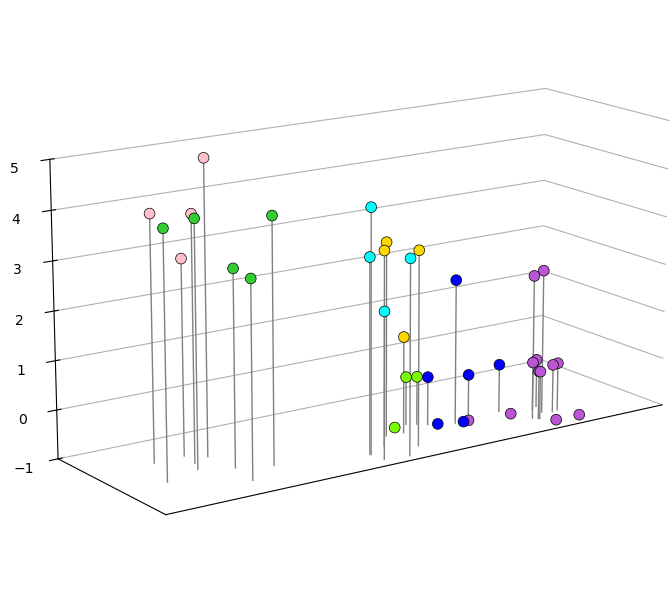

In [51]:
plot_3d_antibody(X,Y,Z,C)

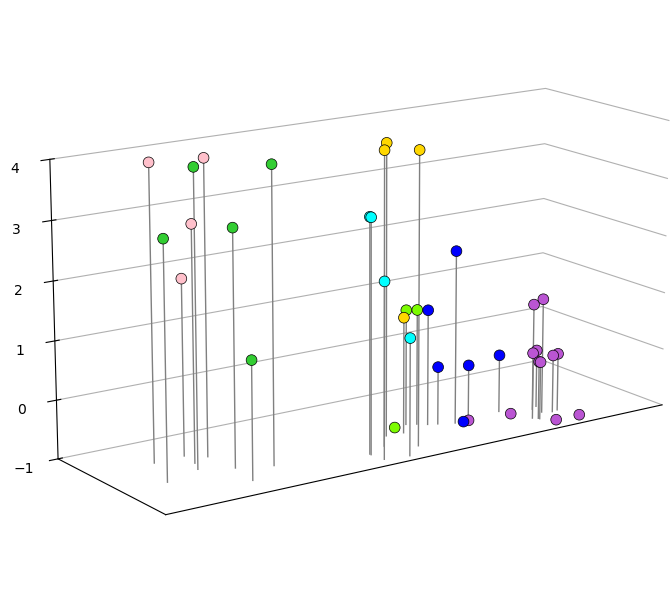

In [52]:
plot_3d_antibody(X_2,Y_2,Z_2,C_2)

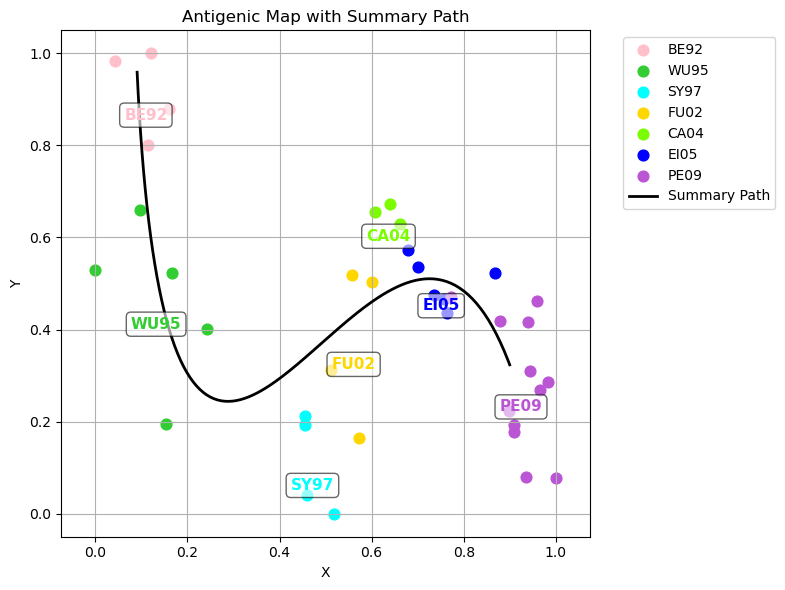

In [53]:
x_smooth,y_smooth,df_centroids=find_summary_path(df_landscape)

the RMSE is :0.9134855666226361


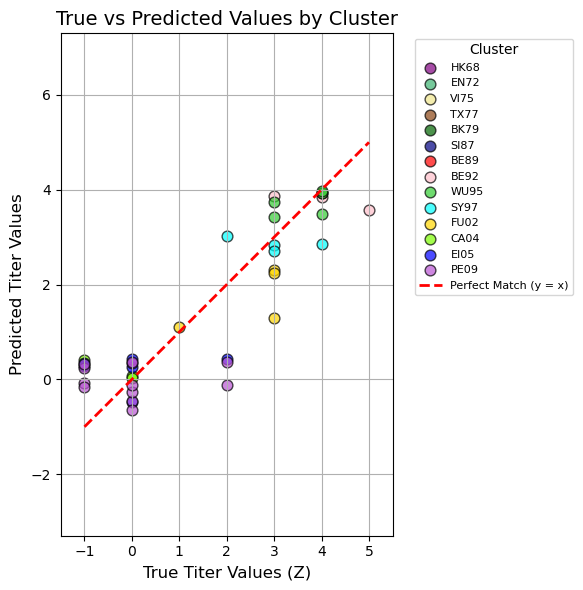

In [54]:
x_range,y_range,landscape_z,predicted_z =compute_surface_regression(X,Y,Z,GRID_SIZE,A,cluster_label,unique_clusters)


the RMSE is :0.9927080680880036


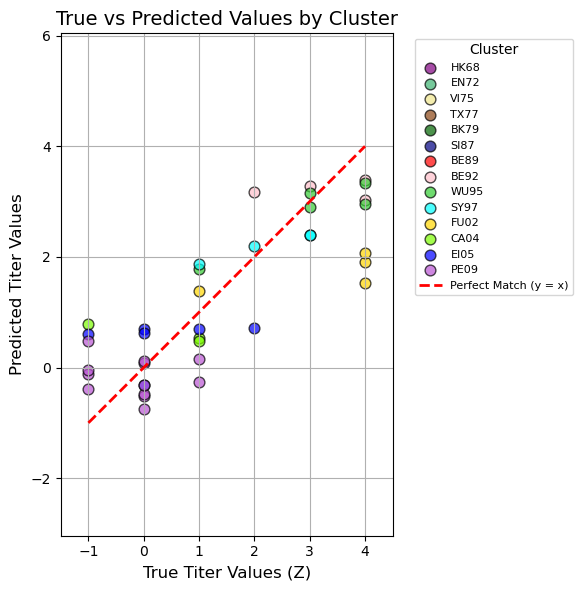

In [55]:
x_range,y_range,landscape_z,predicted_z =compute_surface_regression(X_2,Y_2,Z_2,GRID_SIZE,A,cluster_label,unique_clusters)
